## Q1

In [10]:
from coalmine.constants import N, L
from coalmine.data import load_intervals, accident_dates, mean_rate
from coalmine.plotting import plot_cumulative_accidents

In [11]:
intervals = load_intervals()
print(intervals[:10])
print(intervals.shape)

[157. 123.   2. 124.  12.   4.  10. 216.  80.  12.]
(190,)


<Axes: title={'center': 'Cumulative Coal Mining Accidents (1851–1962)'}, xlabel='Date', ylabel='Cumulative number of accidents'>

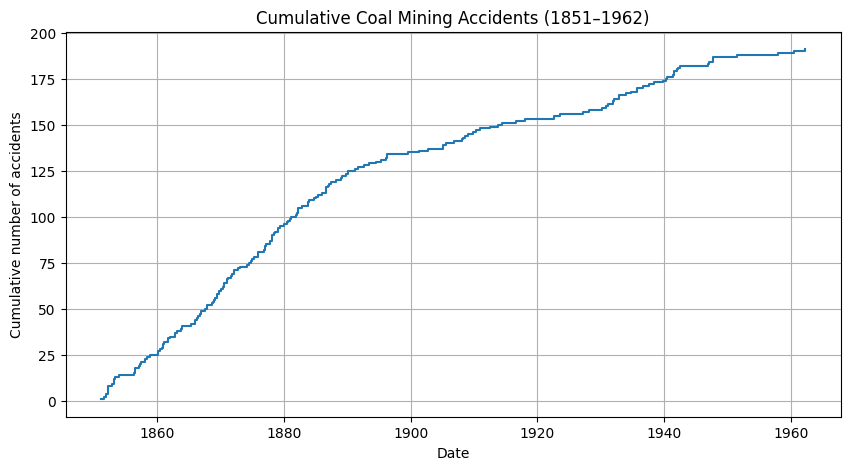

In [12]:
dates = accident_dates(intervals)
plot_cumulative_accidents(dates)

#### Mean Rate

Simply the total number of accidents (191) over the entire time period (40550)

In [13]:
print(f"Mean rate: {mean_rate():.17f} accidents per day")

Mean rate: 0.00471023427866831 accidents per day


## Q2 - Priors

### Q2a — Comparing change-point priors

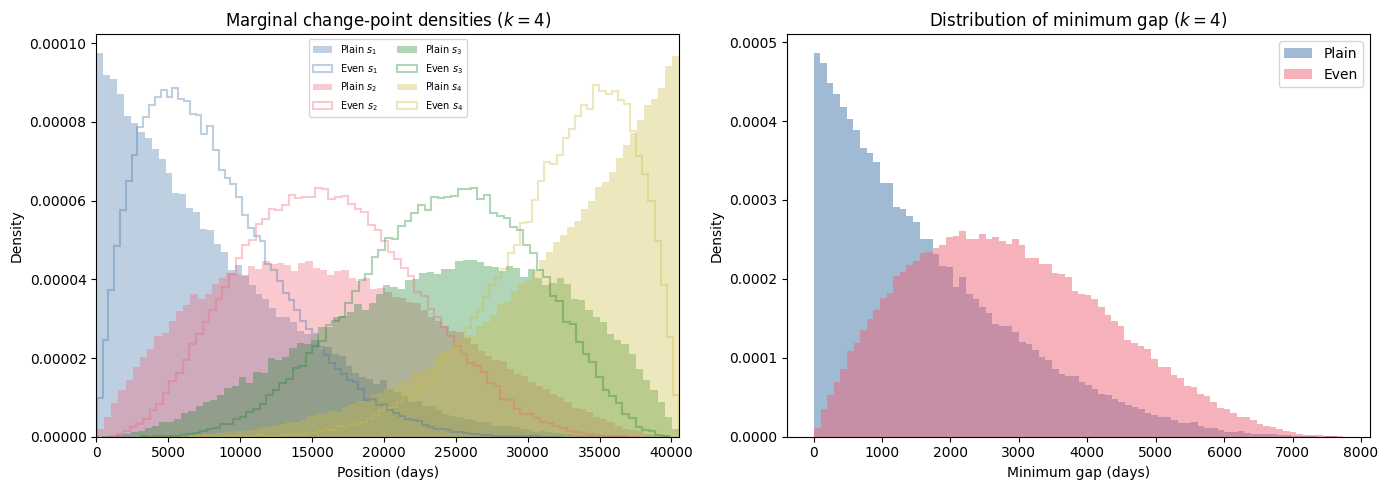

In [14]:
import numpy as np
from coalmine.constants import L
from coalmine.analysis import sample_order_stats
from coalmine.plotting import plot_changepoint_prior_comparison

k = 4
n_samples = 100_000
rng = np.random.default_rng(42)

plain = sample_order_stats(k, n_samples, L, even=False, rng=rng)
even = sample_order_stats(k, n_samples, L, even=True, rng=rng)

# This plot shows the probability distribution of individual change points,
# for s_i, i={1,2,3,4}. You can see how even ordered change points more
# closely align with the midpoint of their position in the range.
fig = plot_changepoint_prior_comparison(plain, even, k, L)

### TODO: add observations about the even and plain order change points, using information from both graphs

### Q2b

PDF of the plain order statistics is a constant:  
$$
P(u_{(1)}, u_{(2)}, \ldots, u_{(2k+1)}) = (2k + 1)!
$$

To begin, I will consider the points $\hat{s}_j$ on the unit interval, with $\hat{s}_j = u_{(2j)}$.

To get $k$ even ordered change points, we need $2k+1$ plain ordered change points. However, we only care about the probability over the points $\hat{s}_j = u_{(2j)}$, so we have to marginalise out all of the odd points. Consider the point $u_{(2j-1)}$, this is an odd point so I want to marginalise it out. Because the points are ordered, its region of support is bounded by $[\hat{s}_{j-1}, \hat{s}_j]$. Because $u_{(2j-1)}$ is uniformly distributed, the integral is simple:
$$
\int_{\hat{s}_{j-1}}^{\hat{s}_j}1\cdot du_{(2j-1)} = \hat{s}_{j}-\hat{s}_{j-1}
$$

As defined in the question, $s_{j}-s_{j-1} = g_j$.

Marginalising over successive terms in $P(u_{(1)}, u_{(2)}, \ldots, u_{(2k+1)})$, starting with $u_{(1)}$,
$$
\int_{0}^{\hat{s}_1} (2k+1)! \cdot du_{(1)} = \hat{s}_1(2k+1)!
$$

Second term:
$$
\int_{\hat{s}_1}^{\hat{s}_2} \hat{s}_1(2k+1)! \cdot du_{(3)} = \hat{s}_1(\hat{s}_2-\hat{s}_1)(2k+1)!
$$

Continuing this pattern, each successive odd point $u_{(2j-1)}$ contributes a factor of $(\hat{s}_j - \hat{s}_{j-1})$, i.e. the gap $\hat{g}_j$ (using the convention $\hat{s}_0 = 0$, $\hat{s}_{k+1} = 1$). The final odd point $u_{(2k+1)}$ has support $[\hat{s}_k, 1]$ and contributes a factor $(1 - \hat{s}_k) = \hat{g}_{k+1}$. In total there are $k+1$ such integrals, giving:

$$
P(\hat{s}_1, \hat{s}_2, \ldots, \hat{s}_k) = (2k+1)! \prod_{j=1}^{k+1} \hat{g}_j \propto \prod_{j=1}^{k+1} \hat{g}_j
$$

Since scaling to $[0, L]$ via $s_j = L\hat{s}_j$ merely rescales each gap as $g_j = L\hat{g}_j$, the proportionality carries over directly:

$$
\pi(s_1, s_2, \ldots, s_k \mid M_k) \propto \prod_{j=1}^{k+1} g_j
$$

## Q3 - The constant rate model

### a)

**Prior on $h_0$:**
$$
\pi(h_0) = \beta^\alpha\exp(-\beta h_0)/\Gamma(\alpha); \alpha=1,\beta=200\\
\pi(h_0) = 200\exp(-200 h_0)
$$

**Likelihood where $x(t)=h_0$:**
$$
L(\{I_i\} | h_0, M_0) = \frac{h_0^N}{e^{h_0L}}
$$

So un-normalised posterior is
$$
\frac{200h_0^N}{e^{h_0(L+200)}}
$$

To plot the posterior sensibly against the prior, the posterior needs to be normalised. The evidence integral is
$$
Z_0 = \int_0^{\infty} \frac{200h_0^N}{e^{h_0(L+200)}} dh_0
$$

which we use to normalise the posterior

$$Z_0 = 200 \int_0^{\infty} h_0^{N} e^{-h_0(L+200)} dh_0 = 200 \cdot \frac{\Gamma(N+1)}{(L+200)^{N+1}} = \frac{\beta^\alpha \Gamma(\alpha + N)}{(\beta + L)^{\alpha+N}}$$

Analytic log-evidence:  log(Z_0) = -1217.0925
Numerical log-evidence: log(Z_0) = -1217.0925


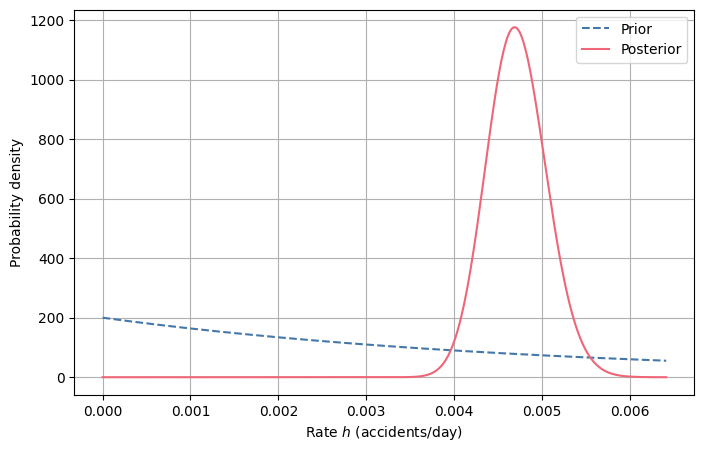

In [15]:
from coalmine.analysis import m0_log_evidence, m0_log_evidence_numerical
from coalmine.plotting import plot_m0_prior_posterior

plot_m0_prior_posterior()

log_Z0_analytic = m0_log_evidence()
log_Z0_numerical = m0_log_evidence_numerical()
print(f"Analytic log-evidence:  log(Z_0) = {log_Z0_analytic:.4f}")
print(f"Numerical log-evidence: log(Z_0) = {log_Z0_numerical:.4f}")

TODO: ADD OBSERVARTIONS ABOUT THE ABOVE PLOT
- Had to take the log evidence because the values are so so small.

## Q4 — The 1 change-point model, $M_1$

### a) MCMC posterior sampling

In [16]:
import pymc as pm
import pytensor.tensor as pt
import corner
import numpy as np
from coalmine.constants import ALPHA, BETA, N, L
from coalmine.data import load_intervals
from coalmine.plotting import CB_COLOURS

intervals = load_intervals()
times = np.insert(np.cumsum(intervals), 0, 0)  # accident times from t=0

with pm.Model() as m1_model:
    # Priors
    h0 = pm.Gamma("h0", alpha=ALPHA, beta=BETA)
    h1 = pm.Gamma("h1", alpha=ALPHA, beta=BETA)
    # Even order statistics prior for k=1: π(s) ∝ s(L-s), i.e. Beta(2,2) on [0,L]
    s1_unit = pm.Beta("s1_unit", alpha=2, beta=2)
    s1 = pm.Deterministic("s1", s1_unit * L)

    # Log-likelihood: Poisson process with rates h0 before s1, h1 after
    # Each event at time t_i contributes log(h0) if t_i < s1, else log(h1)
    # Use a smooth sigmoid approximation to avoid discontinuities for NUTS
    weight = pt.sigmoid((s1 - times[:-1]) / 10.0)  # ≈1 before s1, ≈0 after
    log_rates = weight * pt.log(h0) + (1 - weight) * pt.log(h1)
    loglik = pt.sum(log_rates) - h0 * s1 - h1 * (L - s1)
    pm.Potential("loglik", loglik)

    # Sample
    trace = pm.sample(5000, tune=2000, cores=2, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [h0, h1, s1_unit]


/Users/rowandauria/Documents/MPhil/S2/s2-coursework/venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 2_000 tune and 5_000 draw iterations (4_000 + 10_000 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [17]:
# Diagnostics
print(pm.summary(trace, var_names=["h0", "h1", "s1"]))

         mean       sd     hdi_3%    hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
h0      0.009    0.001      0.007      0.010      0.000    0.000    2910.0   
h1      0.003    0.000      0.002      0.003      0.000    0.000    2215.0   
s1  14451.230  809.775  12972.975  15966.085     32.931   30.285     690.0   

    ess_tail  r_hat  
h0    2996.0    1.0  
h1    2709.0    1.0  
s1     531.0    1.0  


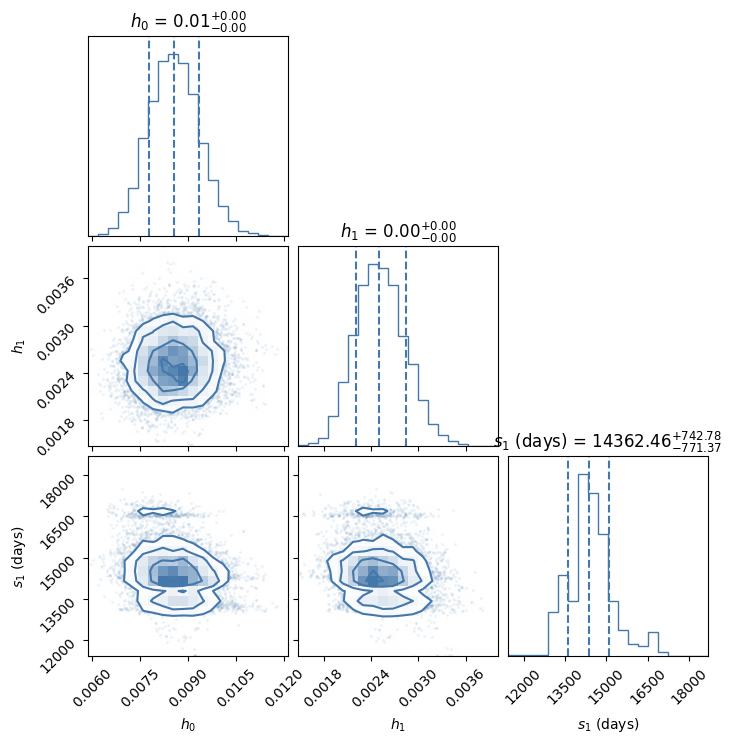

In [18]:
# Corner plot
samples = np.column_stack([
    trace.posterior["h0"].values.flatten(),
    trace.posterior["h1"].values.flatten(),
    trace.posterior["s1"].values.flatten(),
])

fig = corner.corner(
    samples,
    labels=[r"$h_0$", r"$h_1$", r"$s_1$ (days)"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    color=CB_COLOURS[0],
)